In [228]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [229]:
df = pd.read_csv('../data/raw/fraud_dataset_20260421_200139.csv')

In [230]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valor             100000 non-null  float64
 1   hora              100000 non-null  int64  
 2   dispositivo_novo  100000 non-null  bool   
 3   tentativas_24h    100000 non-null  int64  
 4   distancia_km      100000 non-null  float64
 5   fraude            100000 non-null  int64  
dtypes: bool(1), float64(2), int64(3)
memory usage: 3.9 MB


In [231]:
df.describe()

,valor,hora,tentativas_24h,distancia_km,fraude
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2503.391249,11.495150,2.497920,1000.204580,0.190260
std,1440.307090,6.926557,1.708053,576.550141,0.392508
min,10.010000,0.000000,0.000000,0.020000,0.000000
25%,1256.047500,5.000000,1.000000,500.765000,0.000000
50%,2495.860000,11.000000,3.000000,1001.770000,0.000000
75%,3751.900000,18.000000,4.000000,1499.285000,0.000000
max,4999.960000,23.000000,5.000000,1999.980000,1.000000


Text(0.5, 1.0, 'Distribuição das Classes (80974: Legitima, 19026: Fraude)')

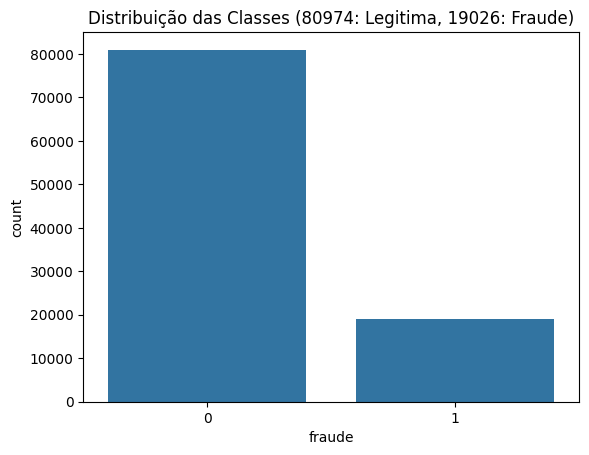

In [232]:
df['fraude'].value_counts()
df_2 = df['fraude'].value_counts()
sns.countplot(x='fraude', data=df)
plt.title(f'Distribuição das Classes ({df_2[0]}: Legitima, {df_2[1]}: Fraude)')

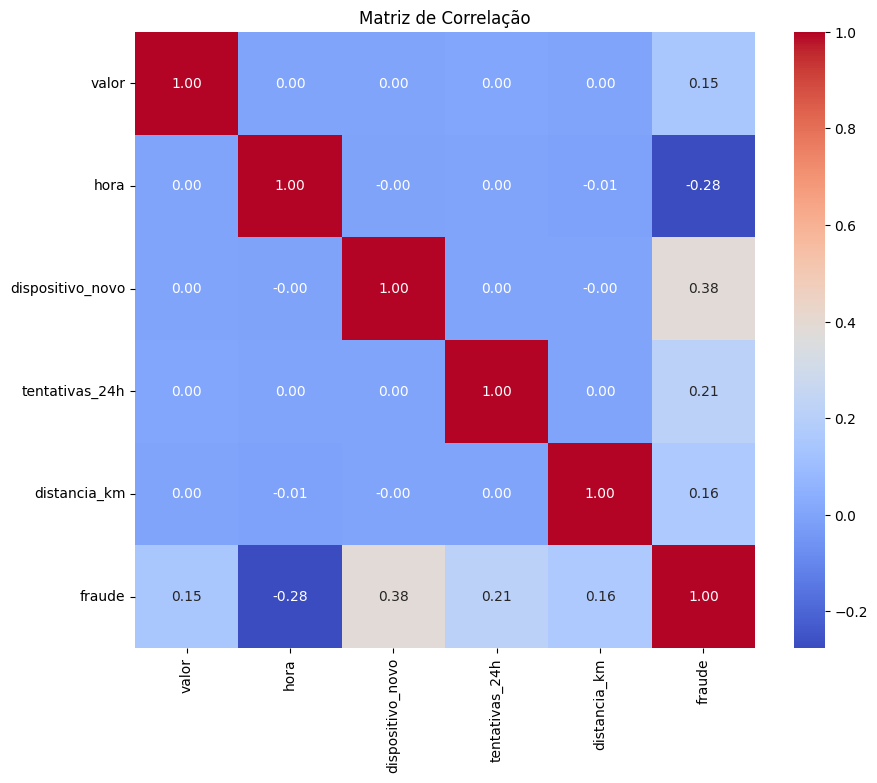

In [233]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

In [234]:
df.corr(numeric_only=True)["fraude"].sort_values(ascending=False)

fraude              1.000000
dispositivo_novo    0.384007
tentativas_24h      0.213398
distancia_km        0.161355
valor               0.146252
hora               -0.275741
Name: fraude, dtype: float64

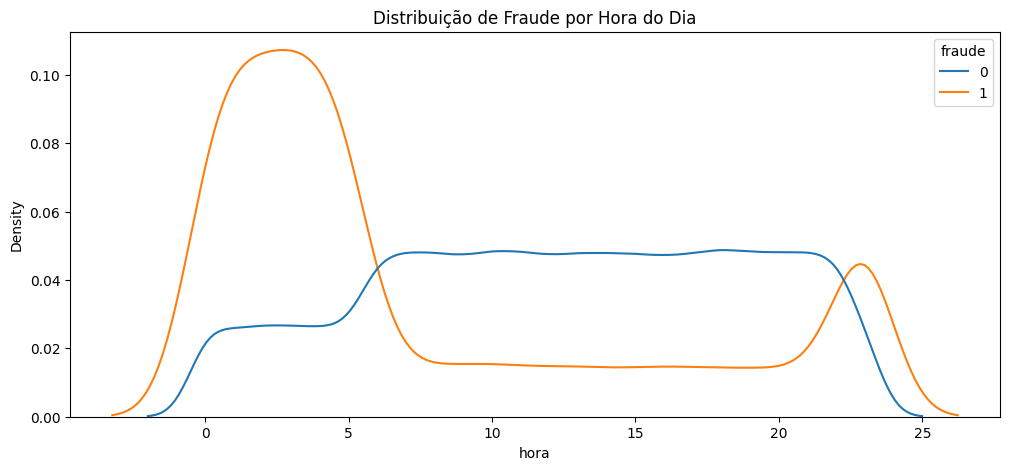

In [235]:
plt.figure(figsize=(12, 5))
sns.kdeplot(data=df, x='hora', hue='fraude', common_norm=False)
plt.title("Distribuição de Fraude por Hora do Dia")
plt.show()

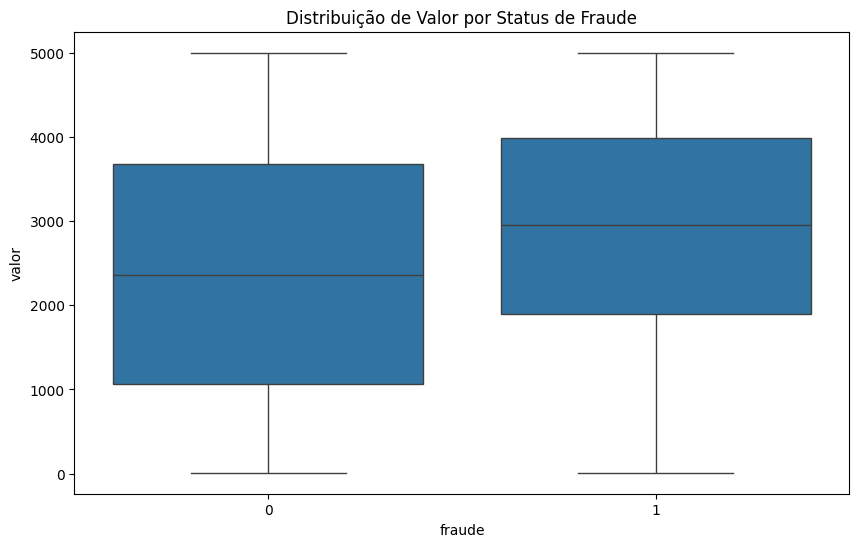

In [236]:
# Comparando Valor e Fraude com Boxplot para ver Outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x='fraude', y='valor', data=df)
plt.title('Distribuição de Valor por Status de Fraude')
plt.show()

In [237]:
taxa_dispositivo = df.groupby('dispositivo_novo')['fraude'].mean()
print(f"Taxa de fraude em dispositivos novos: {taxa_dispositivo[1]:.2%}")
print(f"Taxa de fraude em dispositivos conhecidos: {taxa_dispositivo[0]:.2%}")

Taxa de fraude em dispositivos novos: 34.08%
Taxa de fraude em dispositivos conhecidos: 3.93%


C:\Users\gabriel\AppData\Local\Temp\ipykernel_10020\1751469560.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Taxa de fraude em dispositivos novos: {taxa_dispositivo[1]:.2%}")
C:\Users\gabriel\AppData\Local\Temp\ipykernel_10020\1751469560.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Taxa de fraude em dispositivos conhecidos: {taxa_dispositivo[0]:.2%}")


In [238]:
df.groupby("fraude")["valor"].mean()

fraude
0    2401.284472
1    2937.954172
Name: valor, dtype: float64

In [239]:
df.groupby("dispositivo_novo")["fraude"].mean()

dispositivo_novo
False    0.039333
True     0.340783
Name: fraude, dtype: float64